In [1]:
import numpy as np
import matplotlib.pyplot as plt

from core.IntensityModes import laguerre_gauss as Lg
from core.IntensityModes import hermite_gauss as Hg, hermite_gauss_1d as Hg_1d
from core.Polarization_elements import polarizers,scalar_to_vector, filter_polarizer,q_plate as qp
from core.masks import turbulence_mask as turb
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product as dp
from core.Optical_elements import angular_spectrum as angSpec, tilt, mirror,beam_splitter as bs, lens

4.863879120242253e-32


(<Figure size 640x480 with 1 Axes>, <Axes: >)

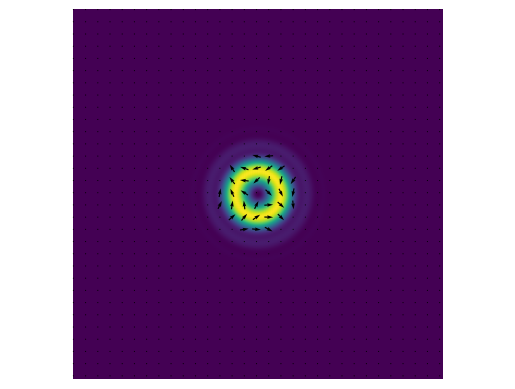

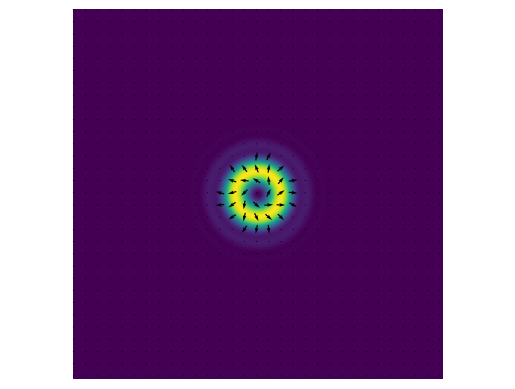

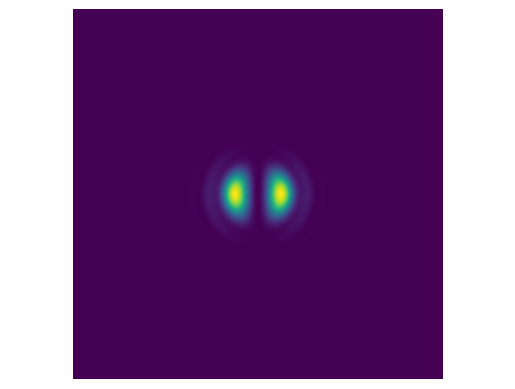

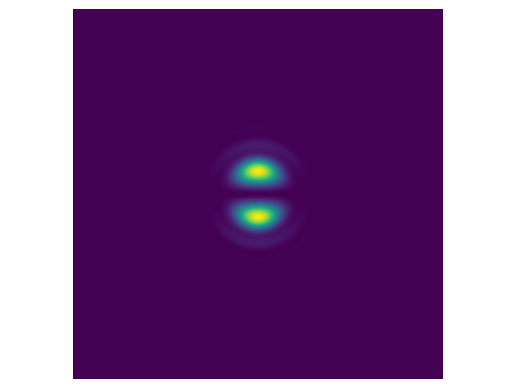

In [30]:
x = np.linspace(-.5e-2,.5e-2,1000)
y = np.linspace(-.5e-2,.5e-2,1000)
x,y = np.meshgrid(x,y)

gauss = Lg(x,y,0,0)
gauss = polarizers(gauss,np.pi/4,'quarter')

gauss = qp(x,y,gauss)

lg,gauss = bs(gauss)

lg = angSpec(lg,x,y,1)
lg = lg[::1,::-1]

gauss = angSpec(gauss,x,y,.5)
gauss = mirror(gauss)
gauss = angSpec(gauss,x,y,.5)
I(gauss,vector_field=True,animate=True)
I(lg,vector_field=True,animate=True)
arm1,arm2 = bs(gauss,lg)

print(pwr(x,y,filter_polarizer(arm1,np.pi/4,'Lcirc')))

arm1 = filter_polarizer(arm1,np.pi/8,'Rcirc')
arm2 = filter_polarizer(arm2,np.pi/1,'linear')
I(arm1,vector_field=False)
I(arm2,vector_field=False)
